In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
# update and load cleaned dataset and keep relevant columns
merged_df = pd.read_csv("merged_demo_mortality_caffeine.csv")
cols = ["SEQN", "ELIGSTAT", "MORTSTAT", "PERMTH_INT", "RIDAGEEX", "RIAGENDR",
        "WTSSCAF2", "WTSSCAF4",
        "SSMX3", "SSMX3LC", "SSMX4", "SSMX4LC", "SSMX5", "SSMX5LC",
        "SSMX6", "SSMX6LC", "SSMX7", "SSMX7LC"]

working_df = merged_df[cols].copy()
working_df.to_csv("working_df.csv", index=False)
df_q4 = working_df[["PERMTH_INT", "SSMX3", "SSMX4", "SSMX5"]].dropna()

# Select predictors and outcome
X = df_q4[['SSMX3', 'SSMX5', 'SSMX4']]
y = df_q4['PERMTH_INT']

# Drop missing values
data = pd.concat([X, y], axis=1).dropna()

X = data[['SSMX3', 'SSMX4', 'SSMX5']]
y = data['PERMTH_INT']

In [ ]:
# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# standardize predictors
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# select k from minimum MSE
k_values = [3, 5, 10, 20, 50, 100]
mse_results = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    mse_results.append(mse)
    
    print(f"k = {k}, MSE = {mse}")

best_k = k_values[np.argmin(mse_results)]
print("Optimal k:", best_k)

k = 3, MSE = 5729.663796637967
k = 5, MSE = 5244.971955719557
k = 10, MSE = 5068.982435424355
k = 20, MSE = 4875.856439114391
k = 50, MSE = 4856.2126966789665
k = 100, MSE = 4855.067499261992
Optimal k: 100


In [8]:
# Retrain using training data and optimal k
best_knn = KNeighborsRegressor(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = best_knn.predict(X_test_scaled)

In [ ]:
# Evaluate model performance using RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 69.678314411745


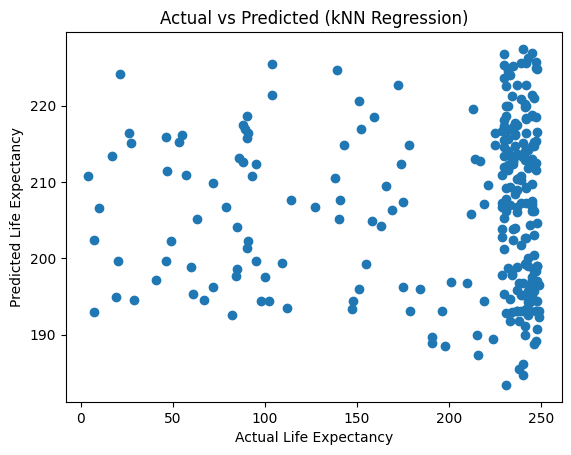

In [10]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted (kNN Regression)")
plt.show()